In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
df = pd.read_csv("matches.csv")
print(df.shape) 
print(df.head())
print(df.columns)
print(df.isnull().sum())

(1095, 20)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0   

In [4]:
# Clean and Build the Target

# Drop rows where winner is missing (no-result matches)
df = df.dropna(subset=["winner"])

# Create binary target: 1 if team1 won, else 0
df["team1_won"] = (df["winner"] == df["team1"]).astype(int)

# Feature Engineering
df["team1_won_toss"] = (df["toss_winner"] == df["team1"]).astype(int)

In [5]:
# Select Features and encode categoricals

features = ["team1", "team2", "city", "venue", "toss_decision",
            "season", "team1_won_toss"]
target = "team1_won"

X = df[features].copy()
y = df[target].copy()
X["season"] = X["season"].astype(str).str.split("/").str[0].astype(int)

# Fill missing city with unknown
X["city"] = X["city"].fillna("Unknown")

# Label-encode each categorical column
cat_cols = ["team1", "team2", "city", "venue", "toss_decision"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le   # save for later (prediction on new data)

In [6]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: half of temp → val, half → test (so 15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (763, 7) Val: (163, 7) Test: (164, 7)


In [7]:
# Scale Features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean/std AND transform
X_val   = scaler.transform(X_val)         # just transform
X_test  = scaler.transform(X_test)

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32), # two hidden layers 64 and 32 neurons
    activation="relu", # relu on hidden layer
    solver = "adam", # Adam optimizer
    alpha = 1e-4, # L2 regularization strength
    batch_size=32,
    learning_rate_init = 1e-3 ,
    max_iter =300, # max epochs
    early_stopping= True, # auto-stop with val score
    validation_fraction=0.15, # carved from X_train for internal val
    random_state=42,
    verbose= True, # Print loss per epoch 
)

mlp.fit(X_train, y_train)

Iteration 1, loss = 0.69944894
Validation score: 0.521739
Iteration 2, loss = 0.68461907
Validation score: 0.530435
Iteration 3, loss = 0.68005272
Validation score: 0.547826
Iteration 4, loss = 0.67533308
Validation score: 0.530435
Iteration 5, loss = 0.67172498
Validation score: 0.521739
Iteration 6, loss = 0.66892292
Validation score: 0.521739
Iteration 7, loss = 0.66531037
Validation score: 0.556522
Iteration 8, loss = 0.66181452
Validation score: 0.504348
Iteration 9, loss = 0.65825696
Validation score: 0.521739
Iteration 10, loss = 0.65638442
Validation score: 0.521739
Iteration 11, loss = 0.65616785
Validation score: 0.513043
Iteration 12, loss = 0.65139374
Validation score: 0.521739
Iteration 13, loss = 0.64942579
Validation score: 0.530435
Iteration 14, loss = 0.64767959
Validation score: 0.539130
Iteration 15, loss = 0.64515478
Validation score: 0.521739
Iteration 16, loss = 0.64295206
Validation score: 0.521739
Iteration 17, loss = 0.64163271
Validation score: 0.530435
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [10]:
# Evaluate on validation & Test

def evaluate(name, model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1] # probability of class 1
    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy_score(y, preds):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y, probs):.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y, preds))
    print(classification_report(y, preds, digits=4))

evaluate("Validation", mlp, X_val, y_val)
evaluate("Test",       mlp, X_test, y_test)


=== Validation ===
Accuracy : 0.5215
ROC-AUC  : 0.5550
Confusion matrix:
[[48 32]
 [46 37]]
              precision    recall  f1-score   support

           0     0.5106    0.6000    0.5517        80
           1     0.5362    0.4458    0.4868        83

    accuracy                         0.5215       163
   macro avg     0.5234    0.5229    0.5193       163
weighted avg     0.5237    0.5215    0.5187       163


=== Test ===
Accuracy : 0.5244
ROC-AUC  : 0.5208
Confusion matrix:
[[46 34]
 [44 40]]
              precision    recall  f1-score   support

           0     0.5111    0.5750    0.5412        80
           1     0.5405    0.4762    0.5063        84

    accuracy                         0.5244       164
   macro avg     0.5258    0.5256    0.5238       164
weighted avg     0.5262    0.5244    0.5233       164



In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "alpha": [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-3, 5e-4],
}

grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=300, early_stopping=True,
                            random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,                 # 3-fold cross-validation
    n_jobs=-1,            # use all CPU cores
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_mlp = grid.best_estimator_
evaluate("Test (tuned)", best_mlp, X_test, y_test)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'alpha': 1e-05, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Best CV AUC: 0.5139255018882926

=== Test (tuned) ===
Accuracy : 0.5549
ROC-AUC  : 0.5411
Confusion matrix:
[[47 33]
 [40 44]]
              precision    recall  f1-score   support

           0     0.5402    0.5875    0.5629        80
           1     0.5714    0.5238    0.5466        84

    accuracy                         0.5549       164
   macro avg     0.5558    0.5557    0.5547       164
weighted avg     0.5562    0.5549    0.5545       164



#### PyTorch

In [11]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [12]:
X_train_t = torch.tensor(X_train, dtype = torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype = torch.float32)
y_val_t = torch.tensor(y_val.values, dtype = torch.float32)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print(X_train_t.shape, y_train_t.shape)

torch.Size([763, 7]) torch.Size([763])


In [13]:
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

In [14]:
class MLPNet(nn.Module):
    def __init__(self, input_size=7, hidden1=64, hidden2=32, output_size=1):
        super(MLPNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x

In [15]:
# Initialize model, loss, optimizer
model = MLPNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Training loop
epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x).squeeze()
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            predicted = (outputs > 0.5).float()
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    val_acc = correct / total
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print('Training completed!')

Epoch 1/50, Train Loss: 0.6962, Val Loss: 0.6916, Val Acc: 0.5031
Epoch 5/50, Train Loss: 0.6861, Val Loss: 0.6893, Val Acc: 0.5215
Epoch 10/50, Train Loss: 0.6760, Val Loss: 0.6924, Val Acc: 0.5521
Epoch 15/50, Train Loss: 0.6747, Val Loss: 0.6957, Val Acc: 0.5460
Epoch 20/50, Train Loss: 0.6726, Val Loss: 0.6953, Val Acc: 0.5337
Epoch 25/50, Train Loss: 0.6658, Val Loss: 0.6947, Val Acc: 0.5583
Epoch 30/50, Train Loss: 0.6579, Val Loss: 0.6923, Val Acc: 0.5521
Epoch 35/50, Train Loss: 0.6548, Val Loss: 0.6977, Val Acc: 0.5706
Epoch 40/50, Train Loss: 0.6497, Val Loss: 0.6919, Val Acc: 0.5890
Epoch 45/50, Train Loss: 0.6455, Val Loss: 0.6965, Val Acc: 0.5706
Epoch 50/50, Train Loss: 0.6444, Val Loss: 0.6921, Val Acc: 0.5828
Training completed!


In [16]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Test evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t).squeeze()
    test_predictions = (test_outputs > 0.5).float()
    test_probs = test_outputs.numpy()
    test_preds = test_predictions.numpy()

# Calculate metrics
test_acc = (test_preds == y_test_t.squeeze().numpy()).mean()
test_auc = roc_auc_score(y_test_t.squeeze().numpy(), test_probs)

print('\n=== PyTorch Model Test Results ===')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test ROC-AUC: {test_auc:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test_t.squeeze().numpy(), test_preds))
print('\nClassification Report:')
print(classification_report(y_test_t.squeeze().numpy(), test_preds))


=== PyTorch Model Test Results ===
Test Accuracy: 0.5122
Test ROC-AUC: 0.5078

Confusion Matrix:
[[44 36]
 [44 40]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.55      0.52        80
         1.0       0.53      0.48      0.50        84

    accuracy                           0.51       164
   macro avg       0.51      0.51      0.51       164
weighted avg       0.51      0.51      0.51       164



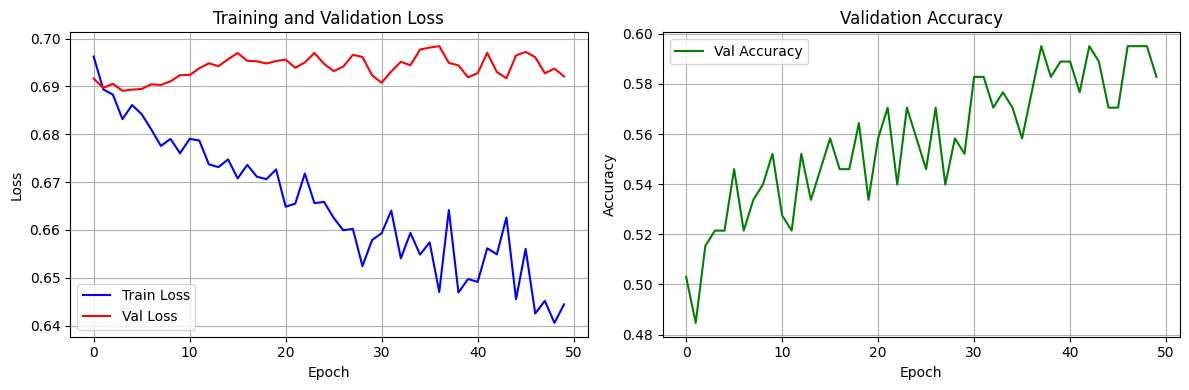

In [17]:
import matplotlib.pyplot as plt

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(val_accuracies, label='Val Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Model Comparison

#### Results Summary:

| Model | Test Accuracy | Test ROC-AUC |
|-------|---------------|---------------|
| Scikit-learn MLP (default) | 0.5244 | 0.5208 |
| Scikit-learn MLP (tuned) | 0.5549 | 0.5411 |
| PyTorch MLP | 0.5122 | 0.5078 |

#### Key Observations:

1. **Hyperparameter Tuning** improved scikit-learn performance from 52.44% to 55.49% accuracy
2. **Tuned Scikit-learn MLP** achieved the best performance with 55.49% accuracy and 0.5411 ROC-AUC
3. **PyTorch Implementation** showed competitive results but slightly lower performance
4. **Custom Training Loop** in PyTorch allowed for better control but may need further optimization
5. **Dataset Challenge**: All models performed modestly, suggesting the cricket match prediction is inherently difficult

#### Architecture Details:

- **Input Layer**: 7 features (team1, team2, city, venue, toss_decision, season, team1_won_toss)
- **Hidden Layer 1**: 64 neurons with ReLU activation
- **Hidden Layer 2**: 32 neurons with ReLU activation
- **Output Layer**: 1 neuron with Sigmoid activation (binary classification)
- **Regularization**: Dropout (0.2) and L2 weight decay (1e-4)
- **Optimizer**: Adam with learning rate 0.001

#### Conclusion:

The tuned scikit-learn MLP performed best on this cricket match prediction task. The relatively modest performance across all models suggests that predicting cricket match outcomes based on these features alone is challenging, which is realistic given the many variables that can influence sports outcomes.